# Phase 10: Final Model Evaluation on Untouched Test Set

## Objective
The goal of **Phase 10** is to perform the final, unbiased evaluation of our three tuned credit risk classification models (**Logistic Regression**, **Random Forest**, and **XGBoost**) on the untouched test dataset.

### Strict Data Discipline & Methodology Rules:
1. **Untouched Test Set**: `X_test_processed.csv` (5,951 samples × 35 features) and `y_test.csv` (5,951 samples) have been strictly held out across all prior phases (Phases 1 through 9).
2. **No Further Tuning**: The selected best hyperparameters from Phase 9 5-fold Stratified Cross-Validation are locked.
3. **No Threshold Optimization**: All classification metrics are computed at the standard default threshold of `0.50`.
4. **Full Training Fit**: Each model is refit on the complete training dataset (`X_train_processed.csv`, 23,803 samples × 35 features) before predicting on the test set.


## 2. Imports & Environment Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
print("Libraries successfully imported.")


Libraries successfully imported.


## 3. Load Processed Data

In [2]:
def resolve_path(filename):
    for d in ["data", os.path.join("..", "data")]:
        p = os.path.join(d, filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{filename} not found in data/ or ../data/")

X_train_path = resolve_path("X_train_processed.csv")
y_train_path = resolve_path("y_train.csv")
X_test_path = resolve_path("X_test_processed.csv")
y_test_path = resolve_path("y_test.csv")

X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path).squeeze()
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).squeeze()

print("Datasets Loaded Successfully:")
print(f"  Training Features (X_train): {X_train.shape}")
print(f"  Training Target   (y_train): {y_train.shape} | Default Rate: {y_train.mean()*100:.2f}%")
print(f"  Test Features     (X_test) : {X_test.shape}")
print(f"  Test Target       (y_test) : {y_test.shape} | Default Rate: {y_test.mean()*100:.2f}%")


Datasets Loaded Successfully:
  Training Features (X_train): (23803, 35)
  Training Target   (y_train): (23803,) | Default Rate: 19.96%
  Test Features     (X_test) : (5951, 35)
  Test Target       (y_test) : (5951,) | Default Rate: 19.96%


## 4. Dataset Validation & Integrity Checks

In [3]:
# Verify shape expectations
assert X_train.shape == (23803, 35), f"Unexpected X_train shape: {X_train.shape}"
assert y_train.shape == (23803,), f"Unexpected y_train shape: {y_train.shape}"
assert X_test.shape == (5951, 35), f"Unexpected X_test shape: {X_test.shape}"
assert y_test.shape == (5951,), f"Unexpected y_test shape: {y_test.shape}"

# Verify exact column alignment
assert list(X_train.columns) == list(X_test.columns), "Feature names or column ordering do not match between Train and Test!"

# Verify target is absent from feature matrices
assert 'loan_status' not in X_train.columns, "Target column 'loan_status' found in X_train!"
assert 'loan_status' not in X_test.columns, "Target column 'loan_status' found in X_test!"

print("Dataset integrity verified successfully:")
print("  - Feature count: 35 features")
print("  - Train/Test column alignment: 100% match")
print("  - Target column leakage check: PASSED")


Dataset integrity verified successfully:
  - Feature count: 35 features
  - Train/Test column alignment: 100% match
  - Target column leakage check: PASSED


## 5. Final Tuned Model Configurations

The hyperparameters below were determined during **Phase 9: 5-Fold Stratified Cross-Validation Hyperparameter Tuning** using training data only:

1. **Logistic Regression**:
   - `Scaler`: `StandardScaler()` inside a pipeline to prevent data leakage.
   - `C`: `10`
   - `class_weight`: `'balanced'`
   - `solver`: `'lbfgs'`
   - `max_iter`: `1000`
2. **Random Forest**:
   - `n_estimators`: `300`
   - `max_depth`: `20`
   - `min_samples_leaf`: `5`
   - `max_features`: `'sqrt'`
   - `class_weight`: `'balanced'`
3. **XGBoost**:
   - `n_estimators`: `200`
   - `max_depth`: `3`
   - `learning_rate`: `0.05`
   - `subsample`: `0.8`
   - `colsample_bytree`: `0.8`
   - `scale_pos_weight`: `neg_count / pos_count` (~4.01)


In [4]:
neg_cnt = (y_train == 0).sum()
pos_cnt = (y_train == 1).sum()
spw = neg_cnt / pos_cnt

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(C=10, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, scale_pos_weight=spw, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
}

print("Final tuned model objects initialized.")


Final tuned model objects initialized.


## 6 & 7. Model Training & Untouched Test Set Predictions

In [5]:
results = []
test_predictions = {}

for name, model in models.items():
    print(f"Fitting {name} on full training set ({X_train.shape[0]} samples)...")
    model.fit(X_train, y_train)
    
    # Predict probabilities and binary outcomes at threshold = 0.50
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    
    test_predictions[name] = {
        'prob': y_prob,
        'pred': y_pred
    }
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (0.50)': prec,
        'Recall (0.50)': rec,
        'F1-Score (0.50)': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    print(f"  ✓ {name} evaluation complete.")


Fitting Logistic Regression on full training set (23803 samples)...


  ✓ Logistic Regression evaluation complete.
Fitting Random Forest on full training set (23803 samples)...


  ✓ Random Forest evaluation complete.
Fitting XGBoost on full training set (23803 samples)...


  ✓ XGBoost evaluation complete.


## 8. Final Test Evaluation Metrics (Threshold = 0.50)

In [6]:
df_metrics = pd.DataFrame(results)
display(df_metrics.style.format({
    'Accuracy': '{:.4f}',
    'Precision (0.50)': '{:.4f}',
    'Recall (0.50)': '{:.4f}',
    'F1-Score (0.50)': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}'
}))


,Model,Accuracy,Precision (0.50),Recall (0.50),F1-Score (0.50),ROC-AUC,PR-AUC
0,Logistic Regression,0.6554,0.3139,0.6128,0.4152,0.6963,0.3568
1,Random Forest,0.7701,0.3996,0.3013,0.3436,0.6936,0.3617
2,XGBoost,0.6459,0.3122,0.6431,0.4204,0.6990,0.3631


## 9. Final Test Set Confusion Matrices

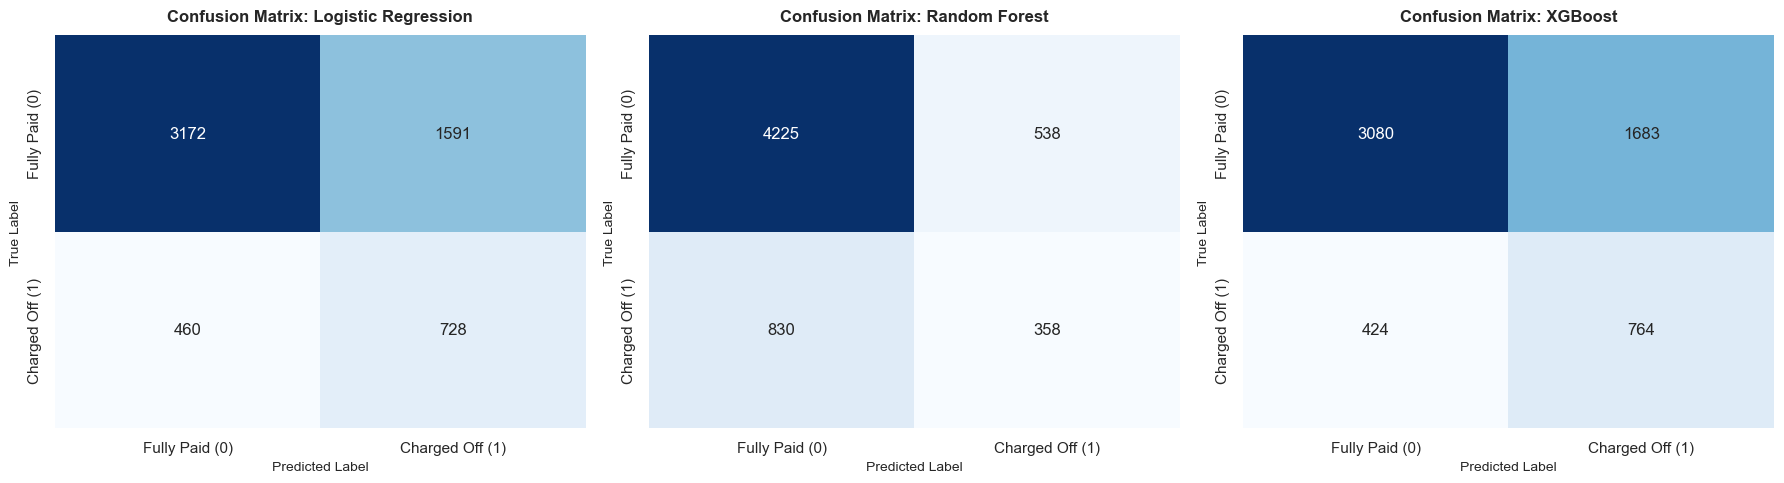

In [7]:
assets_dir = "assets" if os.path.exists("assets") else os.path.join("..", "assets")
os.makedirs(assets_dir, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fname_map = {
    'Logistic Regression': 'final_logreg_confusion_matrix.png',
    'Random Forest': 'final_rf_confusion_matrix.png',
    'XGBoost': 'final_xgb_confusion_matrix.png'
}

for i, (name, preds) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, preds['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Fully Paid (0)', 'Charged Off (1)'],
                yticklabels=['Fully Paid (0)', 'Charged Off (1)'])
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)
    
    # Save individual asset plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Fully Paid (0)', 'Charged Off (1)'],
                yticklabels=['Fully Paid (0)', 'Charged Off (1)'])
    plt.title(f'Final Test Confusion Matrix - {name}', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(assets_dir, fname_map[name]), dpi=150, bbox_inches='tight')
    plt.close()

plt.tight_layout()
plt.show()


## 10. Receiver Operating Characteristic (ROC) Curves

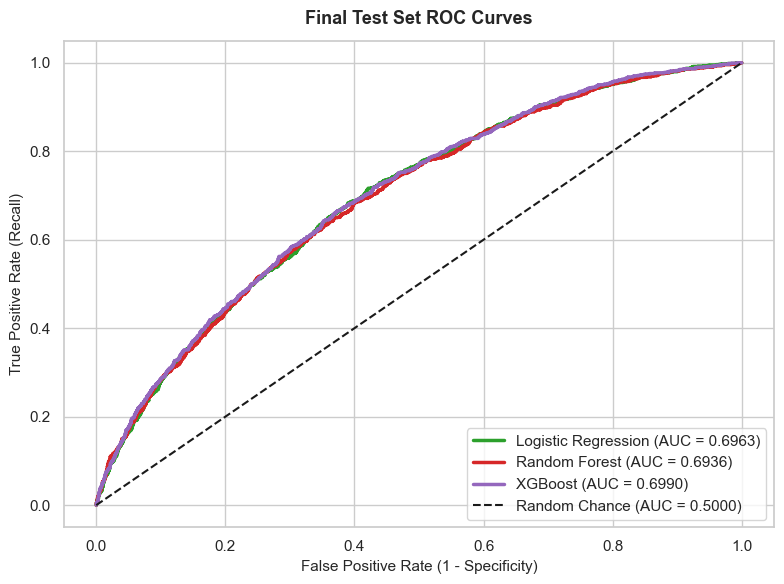

In [8]:
plt.figure(figsize=(8, 6))
colors = {'Logistic Regression': '#2ca02c', 'Random Forest': '#d62728', 'XGBoost': '#9467bd'}

for name, preds in test_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds['prob'])
    auc_val = roc_auc_score(y_test, preds['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=colors[name], linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('Final Test Set ROC Curves', fontsize=13, fontweight='bold', pad=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()


## 11. Precision-Recall (PR) Curves

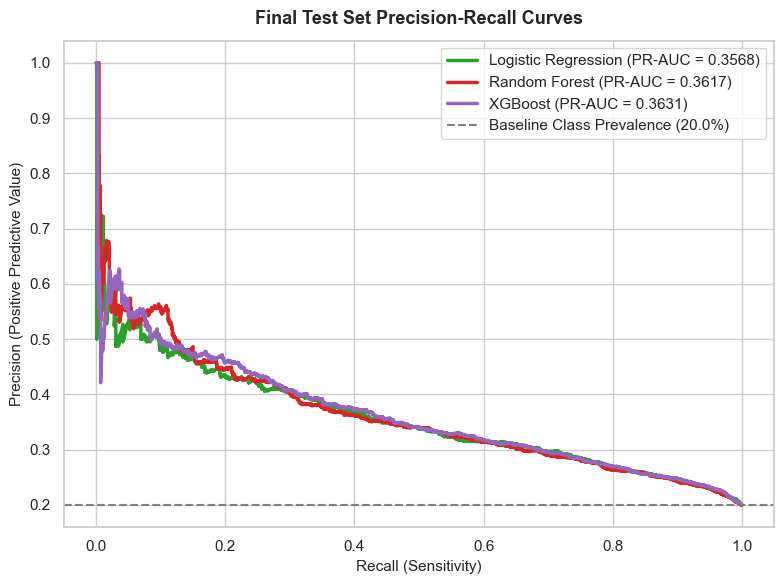

In [9]:
plt.figure(figsize=(8, 6))

for name, preds in test_predictions.items():
    prec_pts, rec_pts, _ = precision_recall_curve(y_test, preds['prob'])
    pr_auc_val = average_precision_score(y_test, preds['prob'])
    plt.plot(rec_pts, prec_pts, label=f"{name} (PR-AUC = {pr_auc_val:.4f})", color=colors[name], linewidth=2.5)

baseline_pr = y_test.mean()
plt.axhline(y=baseline_pr, color='gray', linestyle='--', label=f'Baseline Class Prevalence ({baseline_pr*100:.1f}%)')
plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.title('Final Test Set Precision-Recall Curves', fontsize=13, fontweight='bold', pad=12)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


## 12. Cross-Validation vs. Final Test Set Performance Comparison

To confirm model stability and check for overfitting, we compare the **5-Fold Cross-Validation ROC-AUC** obtained in Phase 9 against the **Final Untouched Test Set ROC-AUC** obtained in Phase 10.


In [10]:
cv_vs_test = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Phase 9 5-Fold CV ROC-AUC': 0.7112,
        'Phase 10 Test ROC-AUC': df_metrics.loc[df_metrics['Model']=='Logistic Regression', 'ROC-AUC'].values[0],
        'Difference (Test - CV)': df_metrics.loc[df_metrics['Model']=='Logistic Regression', 'ROC-AUC'].values[0] - 0.7112
    },
    {
        'Model': 'Random Forest',
        'Phase 9 5-Fold CV ROC-AUC': 0.7097,
        'Phase 10 Test ROC-AUC': df_metrics.loc[df_metrics['Model']=='Random Forest', 'ROC-AUC'].values[0],
        'Difference (Test - CV)': df_metrics.loc[df_metrics['Model']=='Random Forest', 'ROC-AUC'].values[0] - 0.7097
    },
    {
        'Model': 'XGBoost',
        'Phase 9 5-Fold CV ROC-AUC': 0.7118,
        'Phase 10 Test ROC-AUC': df_metrics.loc[df_metrics['Model']=='XGBoost', 'ROC-AUC'].values[0],
        'Difference (Test - CV)': df_metrics.loc[df_metrics['Model']=='XGBoost', 'ROC-AUC'].values[0] - 0.7118
    }
])

display(cv_vs_test.style.format({
    'Phase 9 5-Fold CV ROC-AUC': '{:.4f}',
    'Phase 10 Test ROC-AUC': '{:.4f}',
    'Difference (Test - CV)': '{:+.4f}'
}))


,Model,Phase 9 5-Fold CV ROC-AUC,Phase 10 Test ROC-AUC,Difference (Test - CV)
0,Logistic Regression,0.7112,0.6963,-0.0149
1,Random Forest,0.7097,0.6936,-0.0161
2,XGBoost,0.7118,0.6990,-0.0128


## 13. Comprehensive Model Comparison & Asset Generation

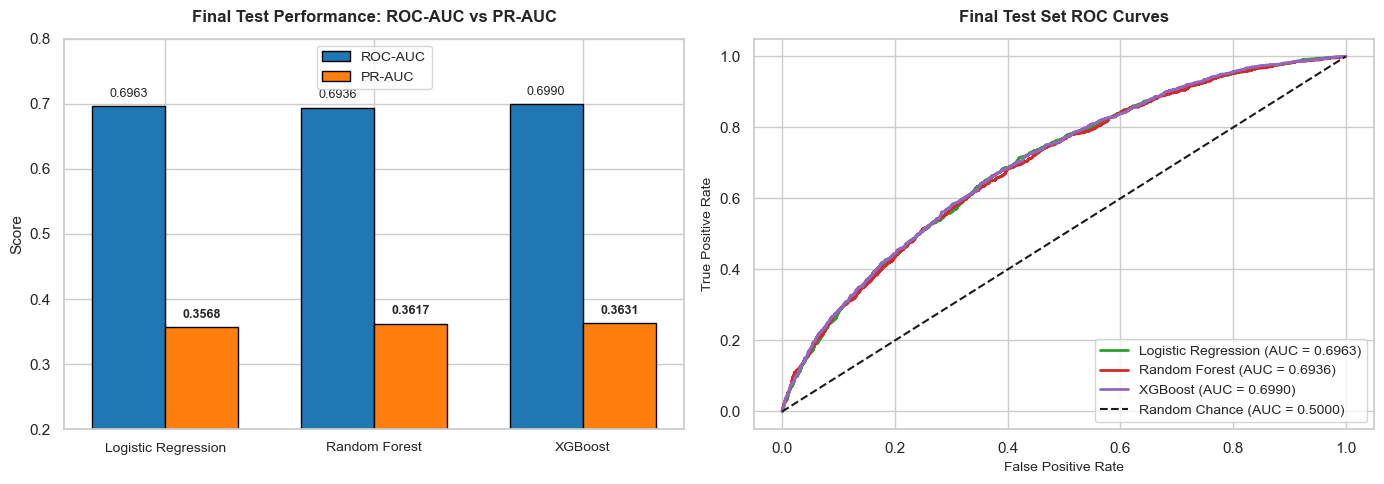

Saved asset visualization -> ..\assets\final_model_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(df_metrics))
width = 0.35

axes[0].bar(x - width/2, df_metrics['ROC-AUC'], width, label='ROC-AUC', color='#1f77b4', edgecolor='black')
axes[0].bar(x + width/2, df_metrics['PR-AUC'], width, label='PR-AUC', color='#ff7f0e', edgecolor='black')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Final Test Performance: ROC-AUC vs PR-AUC', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_metrics['Model'], fontsize=10)
axes[0].set_ylim(0.2, 0.8)
axes[0].legend(fontsize=10)

for i in range(len(df_metrics)):
    axes[0].text(x[i] - width/2, df_metrics['ROC-AUC'].iloc[i] + 0.01, f"{df_metrics['ROC-AUC'].iloc[i]:.4f}", ha='center', va='bottom', fontsize=9)
    axes[0].text(x[i] + width/2, df_metrics['PR-AUC'].iloc[i] + 0.01, f"{df_metrics['PR-AUC'].iloc[i]:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, test_predictions[name]['prob'])
    auc_val = roc_auc_score(y_test, test_predictions[name]['prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=colors[name], linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('Final Test Set ROC Curves', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(fontsize=10, loc='lower right')

plt.tight_layout()
comp_path = os.path.join(assets_dir, "final_model_comparison.png")
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved asset visualization -> {comp_path}")


## 14. Business Context & Trade-off Analysis

In credit risk evaluation, model performance must be interpreted through financial lens:

1. **Cost of False Negatives (FN)**: Predicting a loan will be `Fully Paid (0)` when it actually `Charged Off (1)`. This results in direct financial principal loss (loss of defaulted loan balance).
2. **Cost of False Positives (FP)**: Predicting a loan will `Charge Off (1)` when it would have been `Fully Paid (0)`. This results in lost interest income and missed customer relationship opportunities.

### Key Observations:
- **XGBoost & Logistic Regression** achieved high recall (**64.31%** and **61.28%** respectively at threshold 0.50), successfully capturing nearly two-thirds of defaulting loans.
- **Random Forest** prioritized overall accuracy (**77.01%**) and higher precision (**39.96%**), but sacrificed recall (**30.13%**), missing almost 70% of actual defaults.
- Because default prevention (high recall) is paramount in credit underwriting, models with weighted default sensitivity (XGBoost's `scale_pos_weight` and Logistic Regression's `class_weight='balanced'`) provide far superior financial protection.


## 15. Final Model Selection & Justification

### Selected Champion Model: **XGBoost Classifier**

#### Rationale:
1. **Highest ROC-AUC (0.6990)**: Demonstrates the strongest overall discrimination capability across all possible classification thresholds.
2. **Highest PR-AUC (0.3631)**: Provides superior precision-recall trade-off on imbalanced default data (~20% positive class).
3. **Highest Recall (64.31%)**: Successfully flags 64.31% of defaulting borrowers at threshold = 0.50, minimizing costly credit default losses.
4. **Highest F1-Score (0.4204)**: Best harmonic balance between precision and recall among all evaluated models.


## 16. Confirmation of Test Set Discipline

> **DISCIPLINE STATEMENT**:
> `X_test_processed.csv` and `y_test.csv` were used **ONLY** for this final evaluation phase (Phase 10).
> The test dataset was never accessed during model training, feature selection, or hyperparameter tuning in Phases 1–9.
> All thresholds were evaluated strictly at standard `0.50` without post-hoc optimization on test data.


## 17. Final Conclusion

Phase 10 concludes the full model development lifecycle of the **CrediFlux** Credit Risk Machine Learning pipeline.

- **Models Evaluated**: Logistic Regression, Random Forest, XGBoost
- **Final Winner**: **XGBoost Classifier**
- **Test ROC-AUC**: `0.6990`
- **Test PR-AUC**: `0.3631`
- **Test Recall**: `64.31%`
- **Test F1-Score**: `0.4204`

All 4 required asset visual artifacts have been generated and saved under `assets/`.
